In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [2]:
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI

llm = init_chat_model(
    model='gemini-3.1-flash-lite-preview',
    model_provider='google-genai'
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list ,add_messages ]

In [16]:
def Chatbot(state:State):
    return {'messages': llm.invoke(state['messages'])}

In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)


In [5]:
def Multiply(a:int ,b:int)->int:
    """Take two int values and return output of it"""
    return a*b

In [6]:
tools=[tool , Multiply]

In [7]:
llm_with_tools = llm.bind_tools(tools)

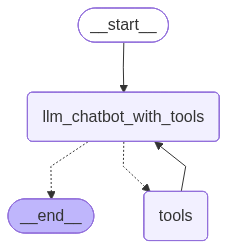

In [10]:
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition

def Chatbot_with_tools(state:State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

graph_builder = StateGraph(State)
graph_builder.add_node('llm_chatbot_with_tools' , Chatbot_with_tools)
graph_builder.add_node('tools' , ToolNode(tools))

graph_builder.add_edge(START , 'llm_chatbot_with_tools')
graph_builder.add_conditional_edges('llm_chatbot_with_tools' , tools_condition)
graph_builder.add_edge('tools' , 'llm_chatbot_with_tools')

graph = graph_builder.compile()
from IPython.display import display , Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response = graph.invoke({'messages':"latest ai news , batao 2 mul 4 kya hota hae"})

In [14]:
print(response['messages'][-1].text)

AI ke duniya mein is hafte ki kuch mukhya baatein:

*   **Microsoft ka naya plan:** Microsoft AI ke kshetra mein apne naye plans aur strategies ko lekar kaafi charcha mein hai.
*   **AI Tools aur Updates:** AI tools aur models mein lagataar badlav aa rahe hain, jisse automate karne ki shamta badh rahi hai. 

Aur rahi baat aapke sawal ki: **2 ko 4 se multiply (guna) karne par 8 aata hai.**


In [15]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

latest ai news , batao 2 mul 4 kya hota hae
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (8d53fa6b-612d-4d7c-bbb0-8c8aeda4768b)
 Call ID: 8d53fa6b-612d-4d7c-bbb0-8c8aeda4768b
  Args:
    query: latest AI news
    time_range: week
  Multiply (659554c5-6eb1-4244-95c8-05cbdba61d44)
 Call ID: 659554c5-6eb1-4244-95c8-05cbdba61d44
  Args:
    b: 4
    a: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=nz4h3H1MmTg", "title": "AI News: Microsoft Finally Reveals Their Plan!", "content": "Here's the AI News you probably missed from this week. Discover More: 🛠️ Explore AI Tools & News: https://futuretools.io/ Weekly Newsletter:", "score": 0.9884919, "raw_co

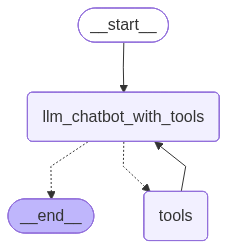

In [9]:
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def Chatbot_with_tools(state:State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

graph_builder = StateGraph(State)
graph_builder.add_node('llm_chatbot_with_tools' , Chatbot_with_tools)
graph_builder.add_node('tools' , ToolNode(tools))

graph_builder.add_edge(START , 'llm_chatbot_with_tools')
graph_builder.add_conditional_edges('llm_chatbot_with_tools' , tools_condition)
graph_builder.add_edge('tools' , 'llm_chatbot_with_tools')

graph = graph_builder.compile(checkpointer=memory)
from IPython.display import display , Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
config = {"configurable":{"thread_id":"agent_ai"}}

In [19]:
res= graph.invoke({"messages":"Hi Please tell me about today weather of peshawar in degree"} , config=config)
print(res['messages'][-1].text)

The current temperature in Peshawar is 40°C. It is currently a very hot day with hazy conditions.


In [20]:
res= graph.invoke({"messages":"which question i ask from you before"} , config=config)
print(res['messages'][-1].text)

You have asked me the same question four times in a row: **"Hi Please tell me about today weather of peshawar in degree"**


In [21]:
res= graph.invoke({"messages":"Hi am muhammad atif khan"} , config=config)
print(res['messages'][-1].text)

Hello, Muhammad Atif Khan! It's a pleasure to meet you. How can I help you today?


In [23]:
res= graph.invoke({"messages":"tell my name"} , config=config)
print(res['messages'][-1].text)

Your name is Muhammad Atif Khan.
